<a href="https://colab.research.google.com/github/baldiea75-tech/carisurg-portfolio/blob/main/week0_triage_eda_day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.makedirs('/content/drive/MyDrive/carisurg-portfolio', exist_ok=True)
print("Folder ready!")

Folder ready!


# New section

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv('EmergencyTriageDataset_Reduced_Dirty.csv')
print(f"Dataset: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print(list(df_raw.columns))

Dataset: 2205 rows x 11 columns
['ID', 'Age', 'Gender', 'GCS', 'SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'Fio2']


In [8]:
print(df_raw['Gender'].unique())
print(df_raw['Gender'].value_counts())

['0' 'Male' 'Female' 'FEMALE' '1' 'MALE']
Gender
1         422
MALE      379
Male      375
FEMALE    366
Female    340
0         323
Name: count, dtype: int64


In [9]:
gender_map = {
      'Male':   1,  'MALE':   1,  '1': 1,
          'Female': 0,  'FEMALE': 0,  '0': 0
}
df_raw['Gender_Clean'] = df_raw['Gender'].map(gender_map)
print(df_raw['Gender_Clean'].value_counts())
print(f"NaNs: {df_raw['Gender_Clean'].isnull().sum()}")

Gender_Clean
1    1176
0    1029
Name: count, dtype: int64
NaNs: 0


In [10]:
df_raw = df_raw.drop(columns=['Gender'])
df_raw = df_raw.rename(columns={'Gender_Clean': 'Gender'})
df_raw.head()

,ID,Age,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2,Gender
0,1,34,15.0,93,67.0,75.67,128.0,36.8,14.0,21.0,0
1,2,20,15.0,130,90.0,103.33,80.0,37.0,16.0,21.0,1
2,3,77,14.0,163,105.0,124.33,92.0,36.8,18.0,21.0,0
3,4,23,8.0,100,60.0,73.33,100.0,37.0,12.0,100.0,0
4,5,86,15.0,150,90.0,110.00,85.0,37.0,19.0,21.0,0


In [11]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_raw)

https://docs.google.com/spreadsheets/d/1RhVXrOTPaKIEowNRU1No423n4U8N3TTDsnH42EiGpYc/edit#gid=0


# New section-Day 2

In [14]:
import os
import glob
import numpy as np
import pandas as pd
from google.colab import drive


# MOUNT DRIVE AND AUTO-LOCATE FILE

try:
    drive.mount("/content/drive")
    print("Drive mounted successfully!")
except Exception as e:
    print("Drive already mounted or running outside Colab.")

# Search Google Drive for the file name automatically
file_search_pattern = "/content/drive/MyDrive/carisurg-portfolio/EmergencyTriageDataset_Reduced_Dirty.csv"
matching_files = glob.glob(file_search_pattern, recursive=True)

if matching_files:
    FILE_PATH = matching_files[0]
    print(f" Found file automatically at: {FILE_PATH}")
else:
    # Fallback to local directory if Google Drive fails completely
    FILE_PATH = "EmergencyTriageDataset_Reduced_Dirty.csv"
    print("File not found in Drive folders")

# Load the dataframe
df = pd.read_csv(FILE_PATH)
print(f"Dataset loaded successfully: {df.shape[0]} rows x {df.shape[1]} columns")
print("=" * 60)


# PART 1: CARISURG BREAKOUT GROUP TEMPLATE — CLEANING THE PULSE COLUMN
COLUMN = "pulse"
VALID_MIN = 20  # Clinically justified minimum for pulse (Reference Table Page 15)
VALID_MAX = 250  # Clinically justified maximum for pulse (Reference Table Page 15)

print(f"=== Cleaning: {COLUMN} ===")
print(f"Original Unique values (Sample): {df[COLUMN].unique()[:15]}")
print(f"Original Dtype: {df[COLUMN].dtype}")
print("-" * 50)

# Convert to numeric, forcing text entry errors into NaNs
df[COLUMN] = pd.to_numeric(df[COLUMN], errors="coerce")
print(f"After type conversion — NaNs found: {df[COLUMN].isnull().sum()}")
print(df[COLUMN].describe())
print("-" * 50)

# Identify and isolate physiologically impossible outliers
invalid_pulse = df[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX)]
print(f"Out-of-range pulse values detected: {len(invalid_pulse)} rows")

# Convert out-of-range values to NaN
df.loc[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX), COLUMN] = np.nan
print(f"Total NaNs before imputation: {df[COLUMN].isnull().sum()}")
print("-" * 50)

# Impute missing entries with the median
impute_value_pulse = df[COLUMN].median()
df[COLUMN] = df[COLUMN].fillna(impute_value_pulse)

print(f"After Cleaning {COLUMN}:")
print(df[COLUMN].describe())
print(f"NaNs remaining: {df[COLUMN].isnull().sum()}")
print("=" * 60)


# PART 2: COMPANION CLEANING FOR SBP (needed for shock index)
print("\n=== Cleaning Companion Column: SBP ===")
COLUMN_SBP = "SBP"
VALID_MIN_SBP = 50
VALID_MAX_SBP = 250

# Convert and filter range
df[COLUMN_SBP] = pd.to_numeric(df[COLUMN_SBP], errors="coerce")
df.loc[
    (df[COLUMN_SBP] < VALID_MIN_SBP) | (df[COLUMN_SBP] > VALID_MAX_SBP),
    COLUMN_SBP,
] = np.nan

# Median Imputation
impute_value_sbp = df[COLUMN_SBP].median()
df[COLUMN_SBP] = df[COLUMN_SBP].fillna(impute_value_sbp)

print(df[COLUMN_SBP].describe())
print("=" * 60)


# ADVANCED CLINICAL RISK FEATURE ENGINEERING (SHOCK FLAG)
print("\n=== Composite Shock Flag ===")

# Create the binary composite flag safely using 1s and 0s
df["shock_flag"] = np.where((df["SBP"] < 90) & (df["pulse"] > 110), 1, 0)

print("--- Clinical Risk Assessment Matrix Complete ---")
print(f"Total Patient Records Audited: {len(df)}")
print(f"High-Risk Decompensated Shock Cases Identified: {df['shock_flag'].sum()}")
print(
    f"Percentage of At-Risk Population: {(df['shock_flag'].sum() / len(df)) * 100:.2f}%"
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
 Found file automatically at: /content/drive/MyDrive/carisurg-portfolio/EmergencyTriageDataset_Reduced_Dirty.csv
Dataset loaded successfully: 2205 rows x 11 columns
=== Cleaning: pulse ===
Original Unique values (Sample): ['128.0' '80.0' '92.0' '100.0' '85.0' '99.0' '78.0' '130.0' '63.0' '98.0'
 '76.0' '166.0' '151.0' '94.0' '87.0']
Original Dtype: object
--------------------------------------------------
After type conversion — NaNs found: 44
count    2161.000000
mean       96.094863
std        31.035460
min         0.000000
25%        80.000000
50%        90.000000
75%       108.000000
max       300.000000
Name: pulse, dtype: float64
--------------------------------------------------
Out-of-range pulse values detected: 43 rows
Total NaNs before imputation: 87
--------------------------------------------------
After Cleaning pulse

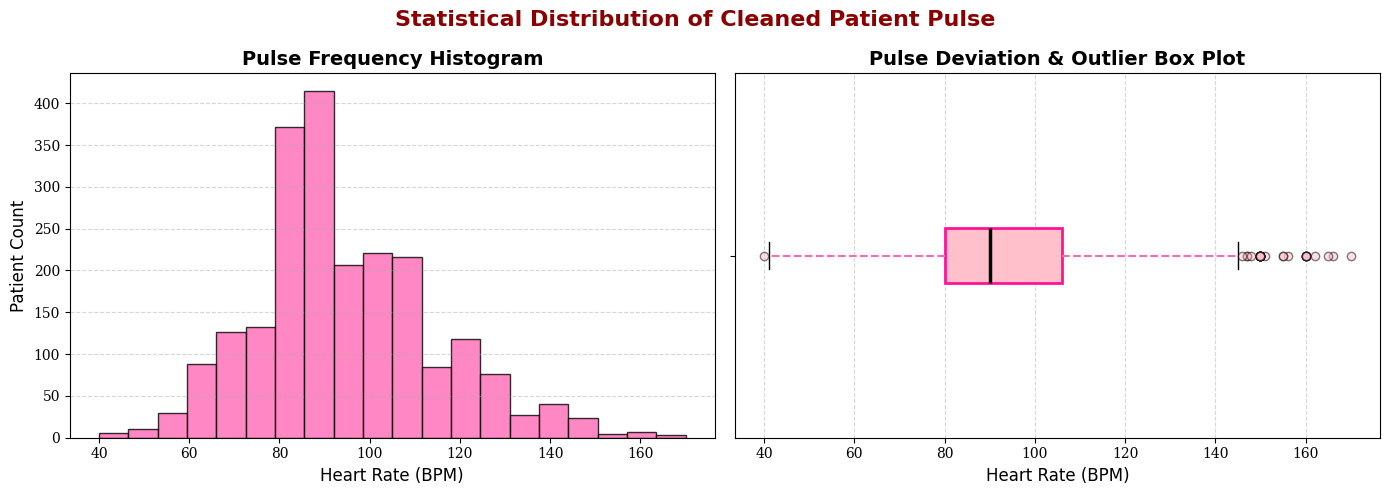

In [15]:
import matplotlib.pyplot as plt

# Set global font to Times New Roman style
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

# Create a clean, side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Statistical Distribution of Cleaned Patient Pulse",
    fontsize=16,
    fontname="Times New Roman",
    weight="bold",
    color="darkred",
)

# GRAPH 1: HISTOGRAM (Distribution Count)
axes[0].hist(
    df["pulse"], bins=20, edgecolor="black", color="hotpink", alpha=0.8
)
axes[0].set_title(
    "Pulse Frequency Histogram",
    fontsize=14,
    fontname="Times New Roman",
    weight="bold",
)
axes[0].set_xlabel(
    "Heart Rate (BPM)", fontsize=12, fontname="Times New Roman"
)
axes[0].set_ylabel(
    "Patient Count", fontsize=12, fontname="Times New Roman"
)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# GRAPH 2: DEVIATION BOX PLOT (Visualizing Spread & Variances)
# Custom styling of the box plot markers
box_props = dict(linestyle="-", linewidth=2, color="deeppink")
whisker_props = dict(linestyle="--", linewidth=1.5, color="hotpink")
median_props = dict(linestyle="-", linewidth=2.5, color="black")
flier_props = dict(marker="o", markerfacecolor="pink", markersize=6, alpha=0.5)

axes[1].boxplot(
    df["pulse"],
    vert=False,
    patch_artist=True,
    boxprops=box_props,
    whiskerprops=whisker_props,
    medianprops=median_props,
    flierprops=flier_props,
)

# Color the interior of the box pink
for patch in axes[1].patches:
    patch.set_facecolor("pink")

axes[1].set_title(
    "Pulse Deviation & Outlier Box Plot",
    fontsize=14,
    fontname="Times New Roman",
    weight="bold",
)
axes[1].set_xlabel(
    "Heart Rate (BPM)", fontsize=12, fontname="Times New Roman"
)
axes[1].set_yticklabels([])  # Clear the unneeded y-axis label for horizontal box plots
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

# Spacing and render the visual assets
plt.tight_layout()
plt.savefig("pulse_analytics.png", dpi=300, bbox_inches="tight")
plt.show()

# New section-Day 3

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")
FILE_PATH = '/content/drive/MyDrive/carisurg-portfolio/EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# ── Apply all cleaning from Days 1 & 2 ───────────────────────

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


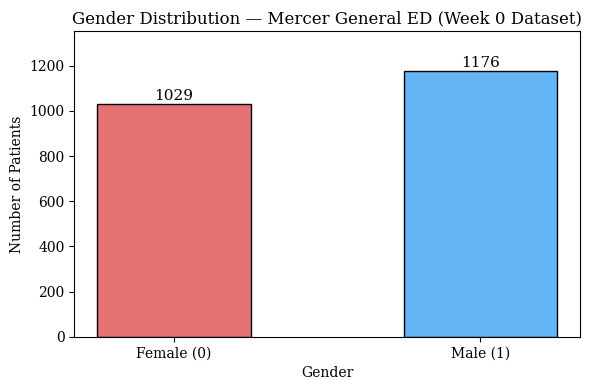

Saved: gender_distribution.png


In [18]:
# Bar plot: Gender distribution
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['Gender'].value_counts().sort_index()
bars = ax.bar(['Female (0)', 'Male (1)'], counts.values,
              color=['#E57373', '#64B5F6'], edgecolor='black', width=0.5)

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=11)

ax.set_title('Gender Distribution — Mercer General ED (Week 0 Dataset)', fontsize=12)
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: gender_distribution.png")

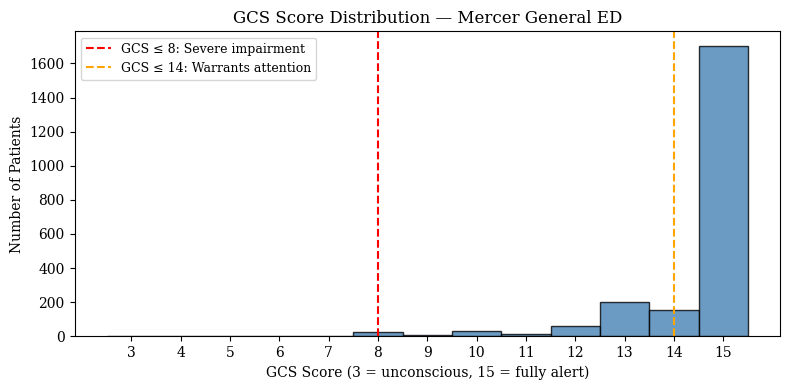

Saved: gcs_histogram.png


In [19]:
# Histogram: GCS distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['GCS'], bins=range(3, 17), edgecolor='black',
        color='steelblue', alpha=0.8, align='left')

# Add a vertical line at the clinical threshold for severe impairment
ax.axvline(x=8, color='red', linestyle='--', linewidth=1.5,
           label='GCS ≤ 8: Severe impairment')
ax.axvline(x=14, color='orange', linestyle='--', linewidth=1.5,
           label='GCS ≤ 14: Warrants attention')

ax.set_title('GCS Score Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('GCS Score (3 = unconscious, 15 = fully alert)')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(3, 16))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('gcs_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: gcs_histogram.png")

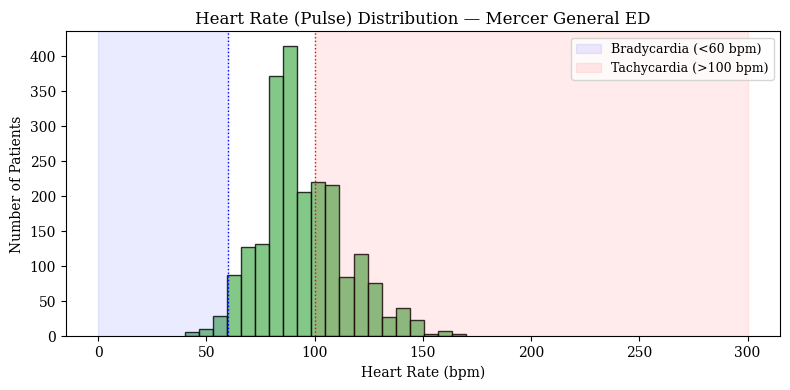

Saved: pulse_histogram.png


In [20]:
# Histogram: Pulse (heart rate) distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['pulse'], bins=20, edgecolor='black', color='#66BB6A', alpha=0.8)

# Clinical reference zones
ax.axvspan(0, 60, alpha=0.08, color='blue', label='Bradycardia (<60 bpm)')
ax.axvspan(100, 300, alpha=0.08, color='red', label='Tachycardia (>100 bpm)')
ax.axvline(x=60, color='blue', linestyle=':', linewidth=1)
ax.axvline(x=100, color='red', linestyle=':', linewidth=1)

ax.set_title('Heart Rate (Pulse) Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Heart Rate (bpm)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('pulse_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: pulse_histogram.png")

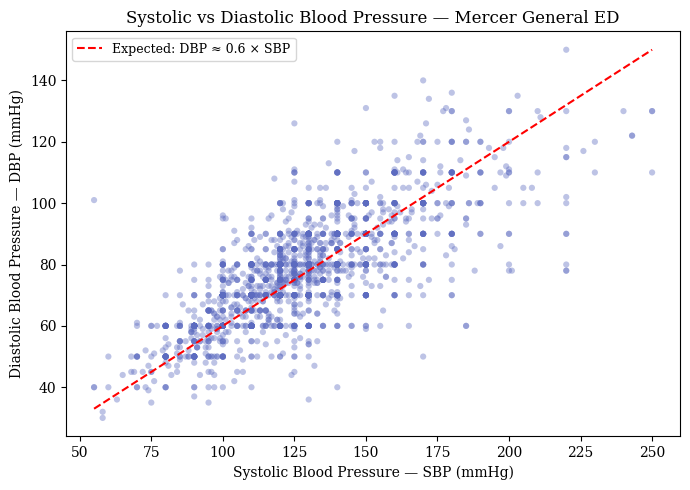

Saved: sbp_vs_dbp.png


In [21]:
# Scatter plot: SBP vs DBP
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['SBP'], df['DBP'],
                     alpha=0.4, s=20, color='#5C6BC0', edgecolors='none')

# Add a trend reference: DBP is typically ~2/3 of SBP
sbp_range = np.linspace(df['SBP'].min(), df['SBP'].max(), 100)
ax.plot(sbp_range, sbp_range * 0.6, color='red', linestyle='--',
        linewidth=1.5, label='Expected: DBP ≈ 0.6 × SBP')

ax.set_title('Systolic vs Diastolic Blood Pressure — Mercer General ED', fontsize=12)
ax.set_xlabel('Systolic Blood Pressure — SBP (mmHg)')
ax.set_ylabel('Diastolic Blood Pressure — DBP (mmHg)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('sbp_vs_dbp.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: sbp_vs_dbp.png")

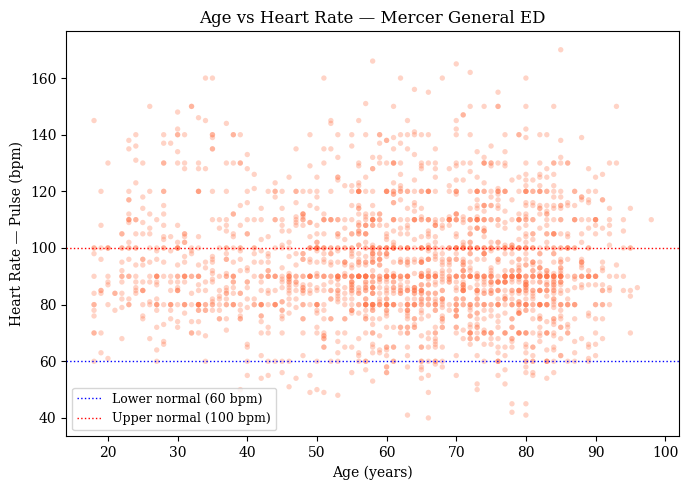

Saved: age_vs_pulse.png


In [22]:
# Scatter plot: Age vs Pulse — does age affect resting heart rate in ED patients?
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['Age'], df['pulse'],
           alpha=0.3, s=15, color='#FF7043', edgecolors='none')

ax.set_title('Age vs Heart Rate — Mercer General ED', fontsize=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Heart Rate — Pulse (bpm)')

# Add clinical reference lines
ax.axhline(y=60, color='blue', linestyle=':', linewidth=1, label='Lower normal (60 bpm)')
ax.axhline(y=100, color='red', linestyle=':', linewidth=1, label='Upper normal (100 bpm)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('age_vs_pulse.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: age_vs_pulse.png")

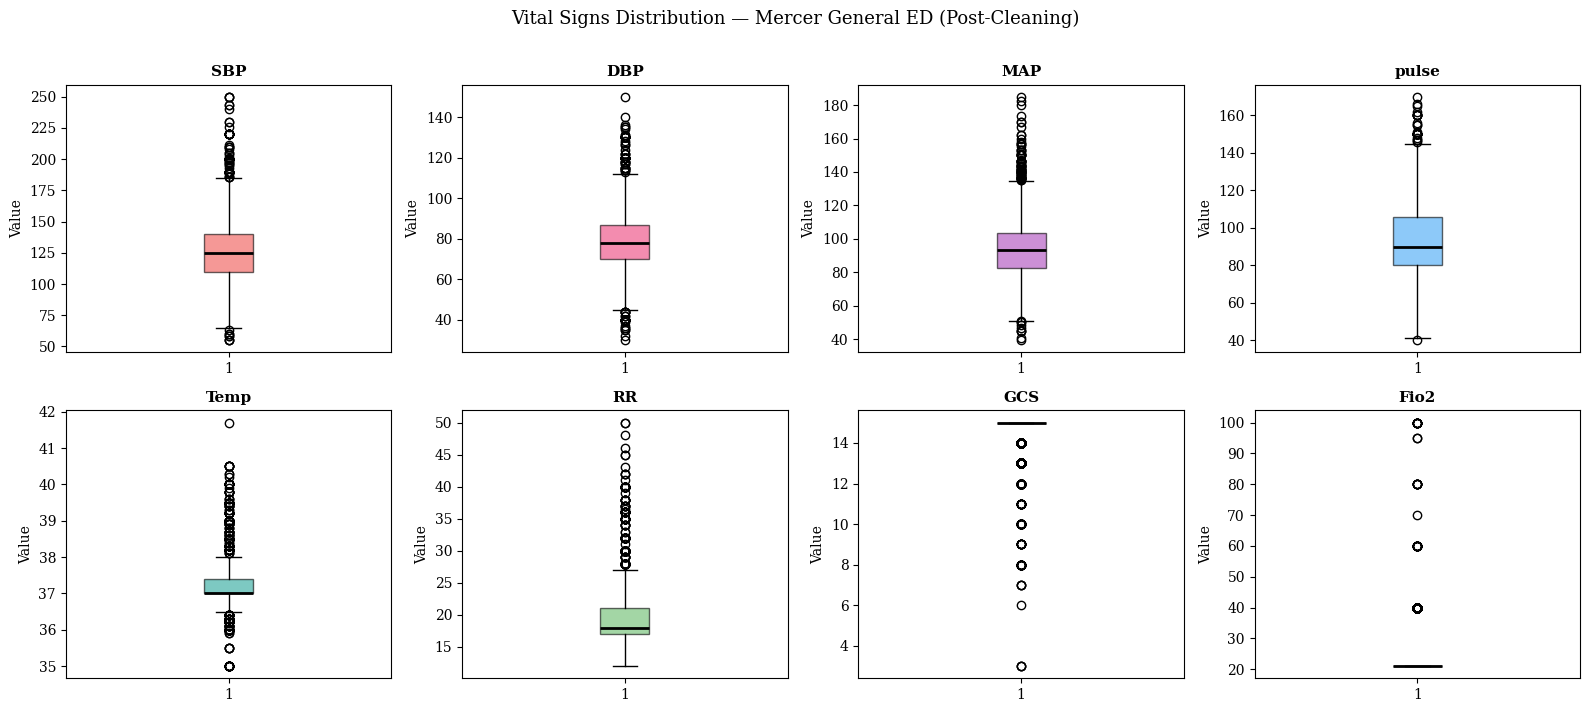

Saved: vitals_boxplots.png


In [23]:
# Box plots for all numeric vitals — side by side for a quick overview
vitals = ['SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'GCS', 'Fio2']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

colors = ['#EF5350','#EC407A','#AB47BC','#42A5F5','#26A69A','#66BB6A','#FFA726','#8D6E63']

for i, (vital, col) in enumerate(zip(vitals, colors)):
    axes[i].boxplot(df[vital].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=col, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(vital, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Vital Signs Distribution — Mercer General ED (Post-Cleaning)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vitals_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: vitals_boxplots.png")

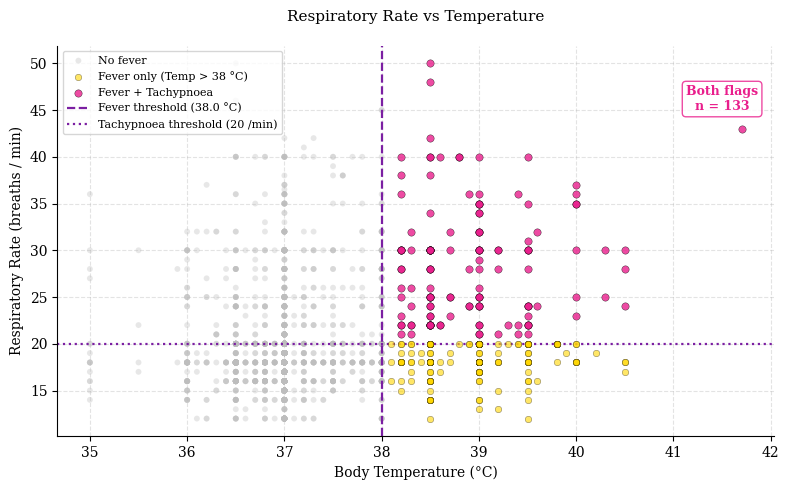

In [24]:
# Colour palette (pink / yellow / purple)
PINK   = "#E91E8C"   # hot pink  — fever + tachypnoea points
YELLOW = "#FFD600"   # gold      — fever-only points
PURPLE = "#7B1FA2"   # deep purple — reference lines / annotations
GREY   = "#BDBDBD"   # neutral   — non-flagged points

# Font: Times New Roman
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "grid.linestyle":    "--",
})

# Build figure
fig, ax = plt.subplots(figsize=(8, 5))

# Colour-code points by clinical zone
# Both fever AND tachypnoea → PINK (highest concern)
# Fever only                → YELLOW
# Neither (or tachypnoea only) → GREY
mask_both  = (df["Temp"] > 38.0) & (df["RR"] > 20)
mask_fever = (df["Temp"] > 38.0) & (df["RR"] <= 20)
mask_other = ~(df["Temp"] > 38.0)

ax.scatter(
    df.loc[mask_other, "Temp"],
    df.loc[mask_other, "RR"],
    alpha=0.35, s=18, color=GREY, edgecolors="none",
    label="No fever",
    zorder=2,
)
ax.scatter(
    df.loc[mask_fever, "Temp"],
    df.loc[mask_fever, "RR"],
    alpha=0.60, s=22, color=YELLOW, edgecolors="black", linewidths=0.3,
    label="Fever only (Temp > 38 °C)",
    zorder=3,
)
ax.scatter(
    df.loc[mask_both, "Temp"],
    df.loc[mask_both, "RR"],
    alpha=0.80, s=28, color=PINK, edgecolors="black", linewidths=0.3,
    label="Fever + Tachypnoea",
    zorder=4,
)

# Clinical reference lines
ax.axvline(
    x=38.0, color=PURPLE, linestyle="--", linewidth=1.6,
    label="Fever threshold (38.0 °C)",
)
ax.axhline(
    y=20, color=PURPLE, linestyle=":",  linewidth=1.6,
    label="Tachypnoea threshold (20 /min)",
)

# Annotate high-risk quadrant count
n_both = mask_both.sum()
ax.annotate(
    f"Both flags\nn = {n_both}",
    xy=(41.5, 45),
    fontsize=9,
    color=PINK,
    fontweight="bold",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor=PINK, alpha=0.8),
)

# Labels, title, legend
ax.set_title(
    "Respiratory Rate vs Temperature\n",
    fontsize=11,
)
ax.set_xlabel("Body Temperature (°C)", fontsize=10)
ax.set_ylabel("Respiratory Rate (breaths / min)", fontsize=10)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("Temperature_vs_Respiratory_Rate.png", dpi=100, bbox_inches="tight")
plt.show()

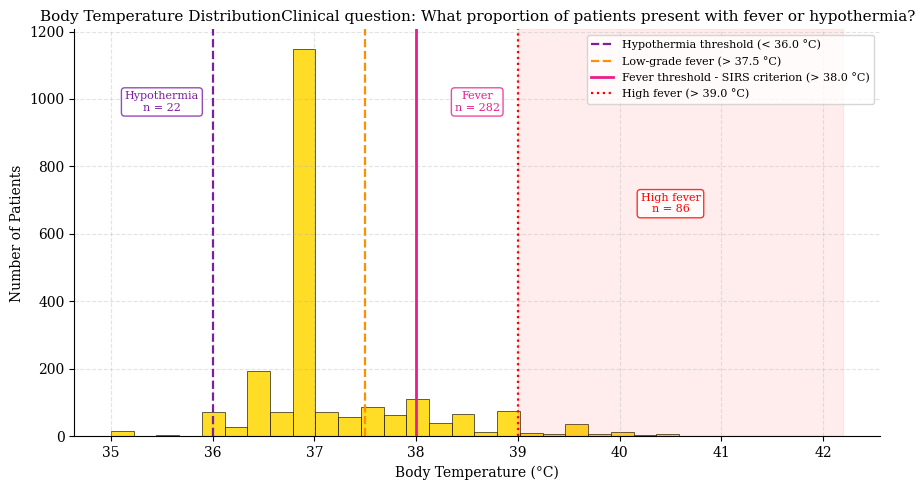

Saved: temp_histogram.png


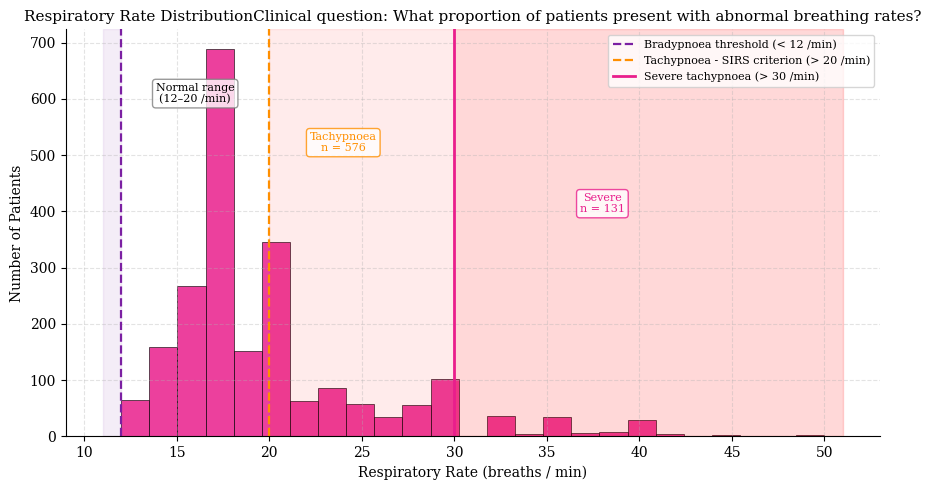

Saved: rr_histogram.png


In [38]:
# HISTOGRAM 1: Body Temperature Distribution

# 1. CLINICAL QUESTION:
#    What proportion of patients present with fever or
#    hypothermia - and how severe is the fever burden?
#
#    From this dataset (n = 2,205):
#      Hypothermia (< 36.0 °C)- 22 patients  (1.0%)
#      Low-grade fever (> 37.5) - 475 patients (21.5%)
#      Fever - SIRS (> 38.0 °C) - 282 patients (12.8%)
#      High fever (> 39.0 °C)- 86 patients  (3.9%)
#
# 2. PLOT TYPE - HISTOGRAM:
#    Temperature is a continuous variable and we want to see the
#    full shape of the distribution, where the bulk of patients
#    sit and whether the ends (hypothermia, high fever) are
#    clinically significant.
#
# 3. REFERENCE LINES AND ANNOTATIONS:
#    Four vertical lines mark the key clinical thresholds:
#      36.0 °C (purple dashed)   - hypothermia lower limit
#      37.5 °C (amber dashed)    - low-grade fever
#      38.0 °C (pink solid)      - SIRS fever criterion
#      39.0 °C (red dotted)      - high fever
#    A shaded red zone (> 39.0 °C) highlights the danger region.
#    Annotated boxes show the patient count in each abnormal zone
#    so the burden is readable directly from the chart.


# Colour palette
PINK   = "#E91E8C"
YELLOW = "#FFD600"
PURPLE = "#7B1FA2"

plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "grid.linestyle":    "--",
})

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["Temp"], bins=30, color=YELLOW, edgecolor="black",
        alpha=0.85, linewidth=0.5)

# Clinical reference lines
ax.axvline(x=36.0, color=PURPLE,    linestyle="--", linewidth=1.6,
           label="Hypothermia threshold (< 36.0 °C)")
ax.axvline(x=37.5, color="#FF8F00", linestyle="--", linewidth=1.6,
           label="Low-grade fever (> 37.5 °C)")
ax.axvline(x=38.0, color=PINK,      linestyle="-",  linewidth=2.0,
           label="Fever threshold - SIRS criterion (> 38.0 °C)")
ax.axvline(x=39.0, color="red",     linestyle=":",  linewidth=1.6,
           label="High fever (> 39.0 °C)")

# Shaded danger zone
ax.axvspan(39.0, df["Temp"].max() + 0.5, alpha=0.07, color="red")

# Annotated patient counts
ylim    = ax.get_ylim()[1]
hypo_n  = (df["Temp"] < 36.0).sum()   # 22
fever_n = (df["Temp"] > 38.0).sum()   # 282
high_n  = (df["Temp"] > 39.0).sum()   # 86

ax.text(35.5, ylim * 0.80, f"Hypothermia\nn = {hypo_n}",
        color=PURPLE, fontsize=8, ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=PURPLE, alpha=0.8))
ax.text(38.6, ylim * 0.80, f"Fever\nn = {fever_n}",
        color=PINK, fontsize=8, ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=PINK, alpha=0.8))
ax.text(40.5, ylim * 0.55, f"High fever\nn = {high_n}",
        color="red", fontsize=8, ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="red", alpha=0.8))

ax.set_title(
    "Body Temperature Distribution"
    "Clinical question: What proportion of patients present with fever or hypothermia?",
    fontsize=11)
ax.set_xlabel("Body Temperature (°C)", fontsize=10)
ax.set_ylabel("Number of Patients", fontsize=10)
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("temp_histogram.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: temp_histogram.png")


# HISTOGRAM 2: Respiratory Rate Distribution


# 1. CLINICAL QUESTION:
#    What proportion of patients present with abnormal
#    breathing rates, and how many are in the severe range?
#
#    From this dataset (n = 2,205):
#      Bradypnoea (< 12 /min) - 0 patients  (0.0%)
#      Tachypnoea (> 20 /min) - 576 patients (26.1%)
#      Severe tachypnoea (> 30 /min) - 131 patients  (5.9%)
#
# 2. PLOT TYPE — HISTOGRAM:
#    RR is continuous and we need to see both the central tendency
#    (median = 18 /min, within normal) and the size of the
#    tachypnoeic tail.
#
# 3. REFERENCE LINES AND ANNOTATIONS:
#    Three vertical lines mark the clinical thresholds:
#      12 /min (purple dashed) - lower limit of normal (bradypnoea)
#      20 /min (amber dashed) - SIRS tachypnoea criterion
#      30 /min (pink solid) - severe tachypnoea, urgent review
#    Shaded zones highlight the abnormal regions.
#    Annotated boxes show the patient count per zone

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["RR"], bins=25, color=PINK, edgecolor="black",
        alpha=0.85, linewidth=0.5)

# Shaded clinical zones
ax.axvspan(df["RR"].min() - 1, 12, alpha=0.08, color=PURPLE)
ax.axvspan(20, df["RR"].max() + 1, alpha=0.08, color="red")
ax.axvspan(30, df["RR"].max() + 1, alpha=0.08, color="red")  # double shade severe zone

# Clinical reference lines
ax.axvline(x=12, color=PURPLE,    linestyle="--", linewidth=1.6,
           label="Bradypnoea threshold (< 12 /min)")
ax.axvline(x=20, color="#FF8F00", linestyle="--", linewidth=1.6,
           label="Tachypnoea - SIRS criterion (> 20 /min)")
ax.axvline(x=30, color=PINK,      linestyle="-",  linewidth=2.0,
           label="Severe tachypnoea (> 30 /min)")

# Annotated patient counts
ylim     = ax.get_ylim()[1]
tachy_n  = (df["RR"] > 20).sum()   # 576
severe_n = (df["RR"] > 30).sum()   # 131

ax.text(16, ylim * 0.82, "Normal range\n(12–20 /min)",
        color="black", fontsize=8, ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="grey", alpha=0.8))
ax.text(24, ylim * 0.70, f"Tachypnoea\nn = {tachy_n}",
        color="#FF8F00", fontsize=8, ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#FF8F00", alpha=0.8))
ax.text(38, ylim * 0.55, f"Severe\nn = {severe_n}",
        color=PINK, fontsize=8, ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=PINK, alpha=0.8))

ax.set_title(
    "Respiratory Rate Distribution"
    "Clinical question: What proportion of patients present with abnormal breathing rates?",
    fontsize=11)
ax.set_xlabel("Respiratory Rate (breaths / min)", fontsize=10)
ax.set_ylabel("Number of Patients", fontsize=10)
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("rr_histogram.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: rr_histogram.png")